# **NIH Chest X-Ray Classification**
**Dataset:** `Sohaibsoussi/NIH-Chest-X-ray-dataset-small` (HuggingFace)

## **Environment Setup**

In [18]:
# Install required packages (run once)
!pip install -q datasets

In [19]:
import os, shutil, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization,
    Dropout, Input, GlobalAveragePooling2D, SeparableConv2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import MobileNetV2, DenseNet201
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# GPU Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)   # avoid OOM
    print(f"{len(gpus)} GPU(s) detected and configured:")
    for g in gpus:
        print(f"   {g}")
else:
    print("No GPU found — running on CPU (will be slow)")

print(f"\nTensorFlow version : {tf.__version__}")
print(f"Mixed precision    : will be enabled below")

✅ 1 GPU(s) detected and configured:
   PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

TensorFlow version : 2.20.0
Mixed precision    : will be enabled below


In [20]:
# Enable mixed-precision training (FP16 compute on GPU, FP32 storage)
# Speeds up training ~2x on modern GPUs with negligible accuracy impact
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", mixed_precision.global_policy())

Mixed precision policy: <DTypePolicy "mixed_float16">


## **Dataset Download & Directory Setup**

In [21]:
# Config
BASE_DIR    = "dataset"
TRAIN_DIR   = os.path.join(BASE_DIR, "train")
VAL_DIR     = os.path.join(BASE_DIR, "validation")
TEST_DIR    = os.path.join(BASE_DIR, "test")
IMG_SIZE    = (224, 224)   # MobileNetV2 / DenseNet201
BATCH_SIZE  = 32
EPOCHS      = 20

# Per-split image limits (keeps dataset balanced & manageable)
MAX_TRAIN   = 430
MAX_VAL     = 190
MAX_TEST    = 162
MIN_CLASS   = 400           # classes with fewer images are dropped

print("Configuration loaded.")

Configuration loaded.


In [22]:
# Load HuggingFace Dataset
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)
    print("Cleared old dataset directory.")

ds = load_dataset("Sohaibsoussi/NIH-Chest-X-ray-dataset-small")
label_names = ds["train"].features["labels"].feature.names
print(f"\nSplits   : {list(ds.keys())}")
print(f"Classes  : {len(label_names)} → {label_names}")

Cleared old dataset directory.

Splits   : ['train', 'validation', 'test']
Classes  : 15 → ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']


In [23]:
# Build Folder Structure
for split in ["train", "validation", "test"]:
    for label in label_names:
        os.makedirs(os.path.join(BASE_DIR, split, label.lower()), exist_ok=True)
print("Folder structure created.")

# Save Images per Split
split_map = {"train": "train", "validation": "validation", "test": "test"}

def save_split(hf_split_name, folder_name):
    """Save HuggingFace dataset split to disk as JPEG files."""
    split_data = ds[hf_split_name]
    for i in tqdm(range(len(split_data)), desc=f"Saving {hf_split_name}"):
        sample = split_data[i]
        image  = sample["image"]
        labels = sample["labels"]
        if not labels:
            continue
        label_str  = label_names[labels[0]].lower()
        save_path  = os.path.join(BASE_DIR, folder_name, label_str)
        filename   = os.path.join(save_path, f"{i:06d}.jpg")
        if isinstance(image, Image.Image):
            image.convert("RGB").save(filename)

for hf_split, folder in split_map.items():
    save_split(hf_split, folder)
print("All images saved to disk.")

Folder structure created.


Saving test: 100%|██████████| 1279/1279 [00:23<00:00, 54.51it/s]


✅ All images saved to disk.


In [24]:
# Balance / Trim Dataset
def count_classes(directory):
    return {
        cls: len(os.listdir(os.path.join(directory, cls)))
        for cls in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, cls))
    }

def trim_to(directory, max_count):
    """Remove random files from each class so each has ≤ max_count images."""
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        files = os.listdir(cls_path)
        excess = len(files) - max_count
        if excess > 0:
            to_delete = random.sample(files, excess)
            for f in to_delete:
                os.remove(os.path.join(cls_path, f))

def remove_class(class_name, *directories):
    """Remove a class folder from given directories."""
    for d in directories:
        p = os.path.join(d, class_name)
        if os.path.exists(p):
            shutil.rmtree(p)

# identify classes to keep (> MIN_CLASS images in train)
train_counts  = count_classes(TRAIN_DIR)
drop_classes  = [c for c, n in train_counts.items() if n <= MIN_CLASS]
keep_classes  = [c for c, n in train_counts.items() if n >  MIN_CLASS]

print(f"Dropping {len(drop_classes)} under-represented classes: {drop_classes}")
print(f"Keeping  {len(keep_classes)} classes: {keep_classes}")

for cls in drop_classes:
    remove_class(cls, TRAIN_DIR, VAL_DIR, TEST_DIR)

# trim each split to max counts
trim_to(TRAIN_DIR, MAX_TRAIN)
trim_to(VAL_DIR,   MAX_VAL)
trim_to(TEST_DIR,  MAX_TEST)

# verify
for split_name, split_dir in [("Train", TRAIN_DIR), ("Validation", VAL_DIR), ("Test", TEST_DIR)]:
    counts = count_classes(split_dir)
    total  = sum(counts.values())
    print(f"\n{split_name}: {total} images across {len(counts)} classes")
    for cls, n in sorted(counts.items()):
        print(f"  {cls:30s}: {n}")

Dropping 12 under-represented classes: ['pleural_thickening', 'consolidation', 'emphysema', 'nodule', 'effusion', 'hernia', 'edema', 'fibrosis', 'cardiomegaly', 'mass', 'pneumothorax', 'pneumonia']
Keeping  3 classes: ['no finding', 'atelectasis', 'infiltration']

Train: 1290 images across 3 classes
  atelectasis                   : 430
  infiltration                  : 430
  no finding                    : 430

Validation: 553 images across 3 classes
  atelectasis                   : 177
  infiltration                  : 186
  no finding                    : 190

Test: 480 images across 3 classes
  atelectasis                   : 160
  infiltration                  : 158
  no finding                    : 162


## **Exploratory Data Analysis (EDA)**

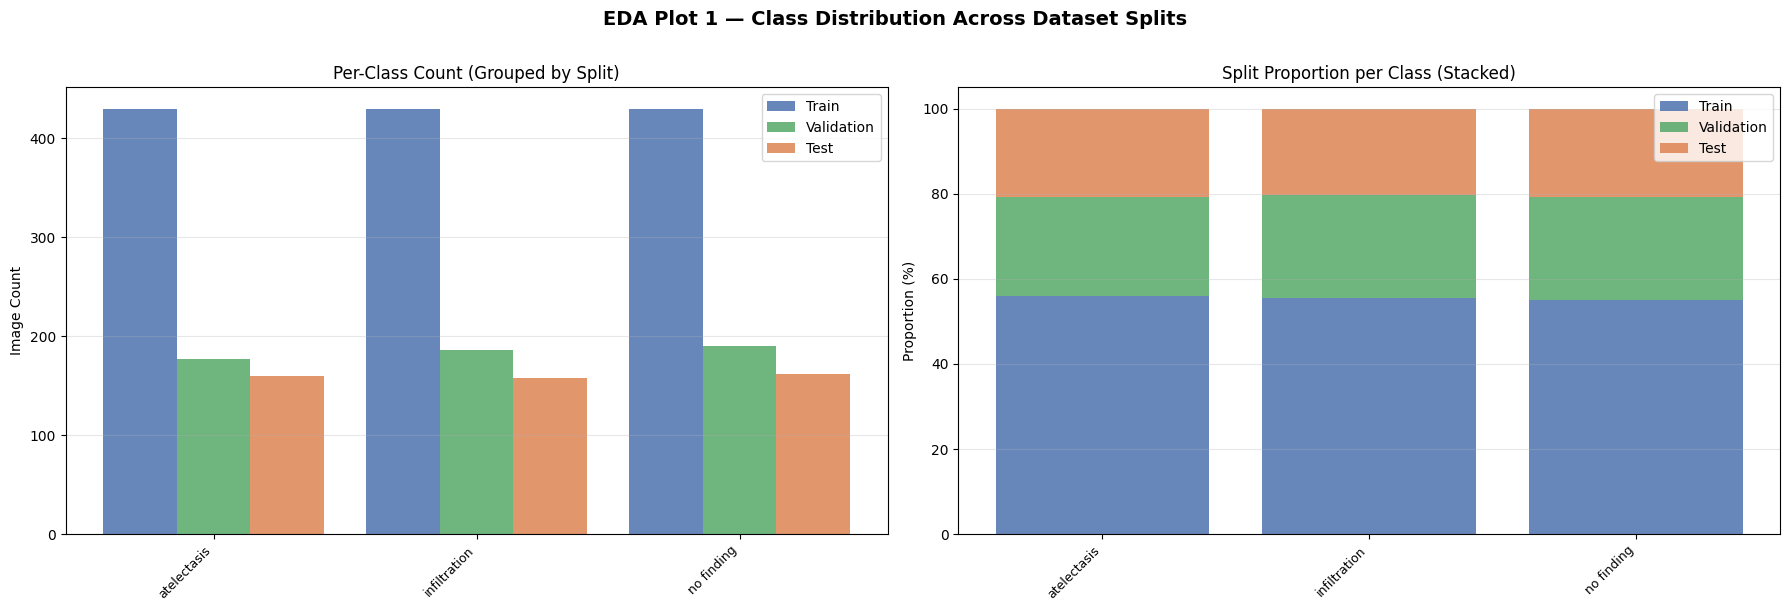

EDA Plot 1 saved.


In [25]:
# Class Distribution Across Splits

splits_info = {
    "Train"     : count_classes(TRAIN_DIR),
    "Validation": count_classes(VAL_DIR),
    "Test"      : count_classes(TEST_DIR),
}

all_classes = sorted(count_classes(TRAIN_DIR).keys())
x = np.arange(len(all_classes))
width = 0.28
colors = ['#4C72B0', '#55A868', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Class Distribution Across Dataset Splits",
             fontsize=14, fontweight='bold', y=1.01)

# Grouped bar chart
ax = axes[0]
for idx, (split_name, color) in enumerate(zip(splits_info, colors)):
    vals = [splits_info[split_name].get(c, 0) for c in all_classes]
    bars = ax.bar(x + idx * width, vals, width, label=split_name, color=color, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(all_classes, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Image Count")
ax.set_title("Per-Class Count (Grouped by Split)")
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Stacked proportion
ax2 = axes[1]
bottom = np.zeros(len(all_classes))
totals = np.array([
    sum(splits_info[s].get(c, 0) for s in splits_info)
    for c in all_classes
], dtype=float)
for split_name, color in zip(splits_info, colors):
    vals = np.array([splits_info[split_name].get(c, 0) for c in all_classes], dtype=float)
    ax2.bar(all_classes, vals / totals * 100, bottom=bottom / totals * 100,
            label=split_name, color=color, alpha=0.85)
    bottom += vals
ax2.set_xticklabels(all_classes, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel("Proportion (%)")
ax2.set_title("Split Proportion per Class (Stacked)")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("eda_plot1_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("EDA Plot 1 saved.")

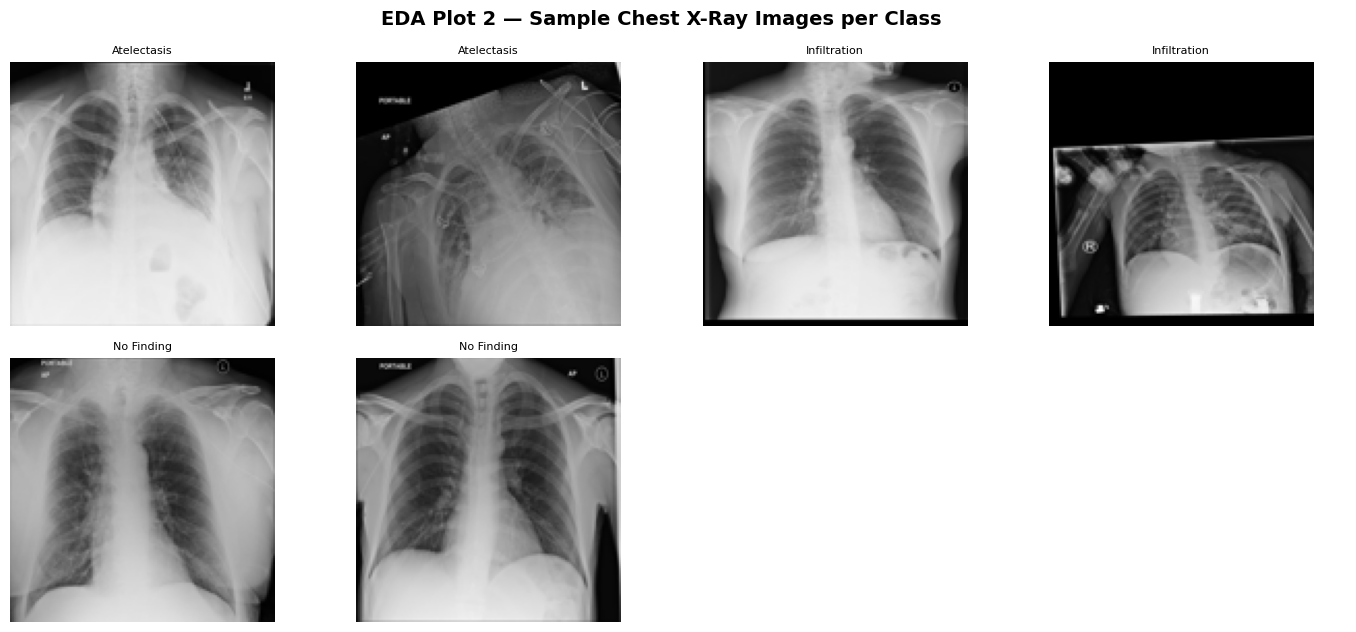

EDA Plot 2 saved.


In [26]:
# 2 sample Images from Each Class

SAMPLES_PER_CLASS = 2
n_classes = len(all_classes)
cols = 4
rows = math.ceil(n_classes * SAMPLES_PER_CLASS / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.2))
axes = axes.flatten()
fig.suptitle("Sample Chest X-Ray Images per Class",
             fontsize=14, fontweight='bold')

plot_idx = 0
for cls in sorted(all_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    files    = os.listdir(cls_path)
    sample   = random.sample(files, min(SAMPLES_PER_CLASS, len(files)))
    for fname in sample:
        img = Image.open(os.path.join(cls_path, fname)).convert("RGB")
        img = img.resize((128, 128))          # small resize for display only
        axes[plot_idx].imshow(img, cmap='gray')
        axes[plot_idx].set_title(cls.replace('_', ' ').title(), fontsize=8)
        axes[plot_idx].axis('off')
        plot_idx += 1

for ax in axes[plot_idx:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig("eda_plot2_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("EDA Plot 2 saved.")

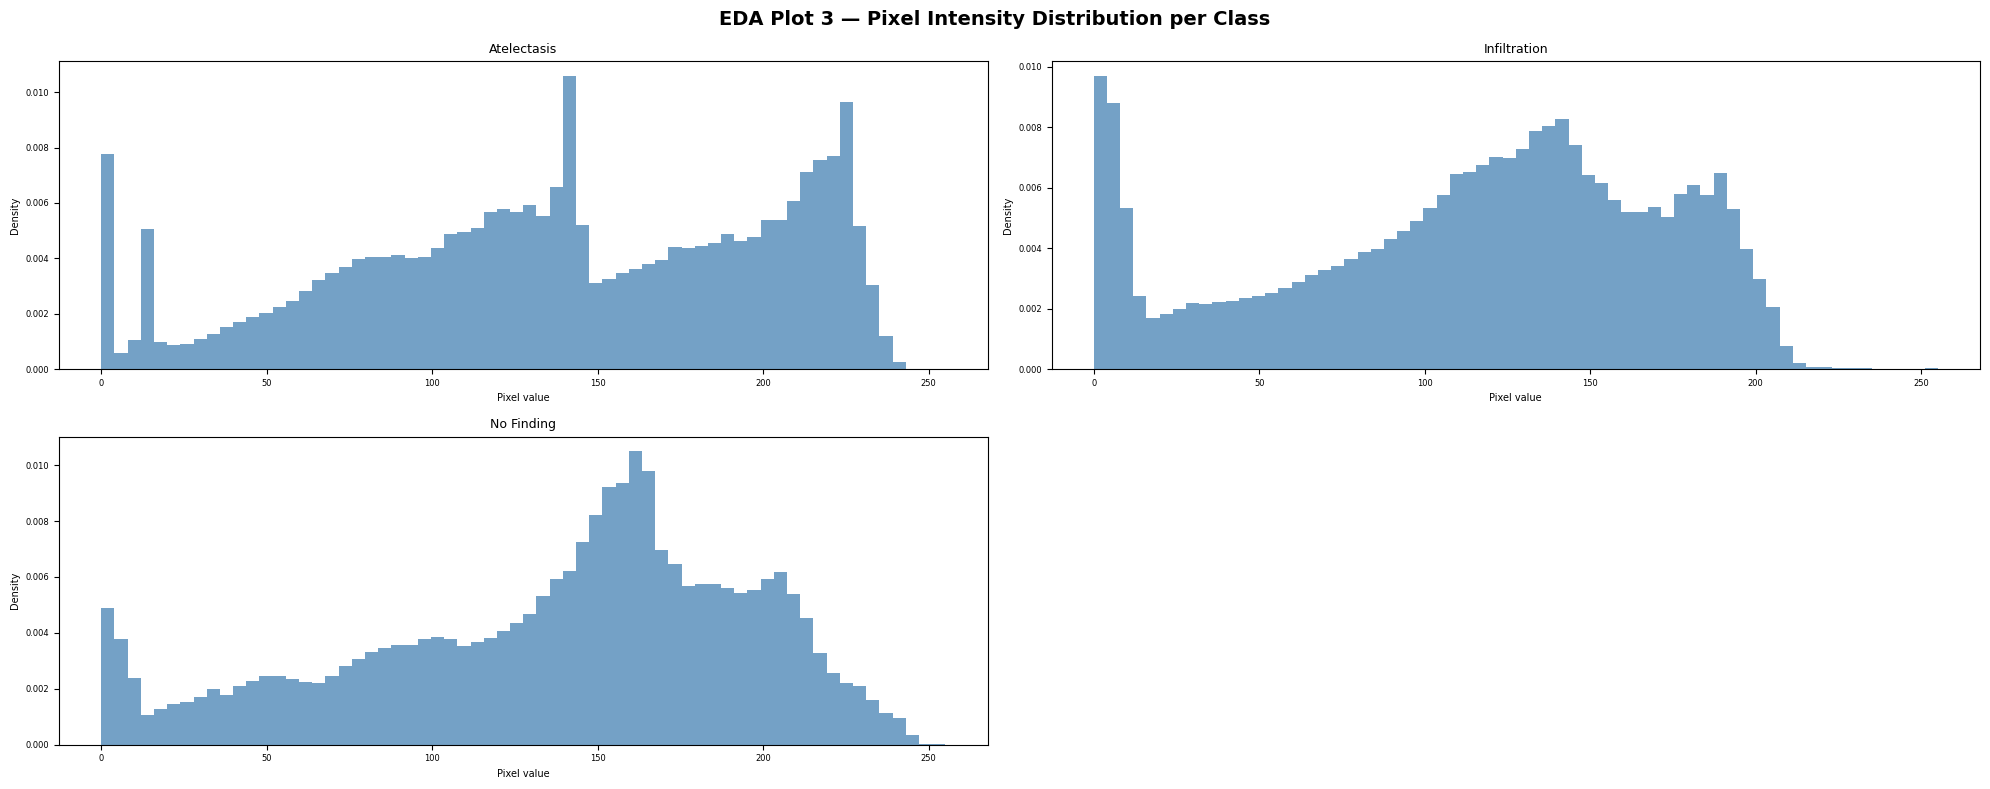

EDA Plot 3 saved.


In [27]:
# Pixel Intensity Distribution per Class

N_SAMPLES = 5   # small sample — fast, illustrative
fig, axes = plt.subplots(2, math.ceil(n_classes / 2), figsize=(20, 8))
axes = axes.flatten()
fig.suptitle("Pixel Intensity Distribution per Class",
             fontsize=14, fontweight='bold')

for idx, cls in enumerate(sorted(all_classes)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    files    = os.listdir(cls_path)
    pixels   = []
    for fname in random.sample(files, min(N_SAMPLES, len(files))):
        img = Image.open(os.path.join(cls_path, fname)).convert("L")  # grayscale
        pixels.extend(np.array(img).flatten().tolist())
    axes[idx].hist(pixels, bins=64, color='steelblue', alpha=0.75, density=True)
    axes[idx].set_title(cls.replace('_', ' ').title(), fontsize=9)
    axes[idx].set_xlabel("Pixel value", fontsize=7)
    axes[idx].set_ylabel("Density",     fontsize=7)
    axes[idx].tick_params(labelsize=6)

for ax in axes[n_classes:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig("eda_plot3_pixel_intensity.png", dpi=150, bbox_inches='tight')
plt.show()
print("EDA Plot 3 saved.")

## **Data Generators & Class Weights**

In [28]:
# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = train_gen.num_classes
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

Found 1290 images belonging to 3 classes.
Found 553 images belonging to 3 classes.
Found 480 images belonging to 3 classes.

Classes (3): ['atelectasis', 'infiltration', 'no finding']


In [29]:
# Class Weights (handle imbalance)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
CLASS_WEIGHTS = dict(enumerate(class_weights_arr))

imbalance_ratio = class_weights_arr.max() / class_weights_arr.min()
print(f"Imbalance ratio  : {imbalance_ratio:.2f}")
print(f"Class weights    :")
for i, w in CLASS_WEIGHTS.items():
    print(f"  {CLASS_NAMES[i]:30s}: {w:.4f}")

Imbalance ratio  : 1.00
Class weights    :
  atelectasis                   : 1.0000
  infiltration                  : 1.0000
  no finding                    : 1.0000


## **Common Callbacks**

In [30]:
def get_callbacks():
    """Shared callbacks for all models."""
    return [
        EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=3,
            min_lr=1e-7, verbose=1
        )
    ]

## **Custom CNN**

In [31]:
# Custom CNN (4-block VGG-style)

def build_custom_cnn(num_classes, img_size):
    inp = Input(shape=(img_size[0], img_size[1], 3))

    # Block 1 — standard conv
    x = Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = Conv2D(32, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)
    x = Dropout(0.25)(x)

    # Block 2
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)
    x = Dropout(0.25)(x)

    # Block 3 — depthwise separable (efficient)
    x = SeparableConv2D(128, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = SeparableConv2D(128, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)
    x = Dropout(0.3)(x)

    # Block 4
    x = SeparableConv2D(256, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = SeparableConv2D(256, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)
    x = Dropout(0.4)(x)

    # Classifier head
    x = GlobalAveragePooling2D()(x)     # lighter than Flatten
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    # dtype='float32' on final layer required with mixed_precision
    out = Dense(num_classes, activation='softmax', dtype='float32')(x)

    return Model(inp, out, name="Custom_CNN")


cnn_model = build_custom_cnn(NUM_CLASSES, IMG_SIZE)
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 56, 56, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 56, 56, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_6              │ (None, 28, 28, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 464,995 (1.77 MB)

 Trainable params: 461,539 (1.76 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [32]:
with tf.device('/GPU:0'):
    cnn_history = cnn_model.fit(
        train_gen, epochs=EPOCHS, validation_data=val_gen,
        class_weight=CLASS_WEIGHTS, callbacks=get_callbacks(), verbose=1
    )
print("Custom CNN training complete.")

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.3186 - loss: 1.7767 - precision: 0.3237 - recall: 0.2682 - val_accuracy: 0.3201 - val_loss: 1.1249 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 559ms/step - accuracy: 0.3659 - loss: 1.5894 - precision: 0.3770 - recall: 0.3078 - val_accuracy: 0.3201 - val_loss: 1.1785 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 28s 683ms/step - accuracy: 0.3822 - loss: 1.5231 - precision: 0.3961 - recall: 0.3132 - val_accuracy: 0.3201 - val_loss: 1.2680 - val_precision: 0.3201 - val_recall: 0.3201 - learning_rate: 1.0000e-04
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.3200 - loss: 1.5813 - precision: 0.3226 - recall: 0.2608
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
41/41 ━━━━━━━━━━━━━━━━━━━━ 45s 780ms/step - accuracy: 0.3473 - loss: 

## **MobileNetV2 (Transfer Learning)**

In [33]:
def build_mobilenetv2(num_classes, img_size):
    base = MobileNetV2(
        input_shape=(img_size[0], img_size[1], 3),
        include_top=False, weights='imagenet'
    )
    # Phase 1: freeze all base layers
    base.trainable = False

    inp = Input(shape=(img_size[0], img_size[1], 3))
    x   = base(inp, training=False)
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(256, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax', dtype='float32')(x)

    return Model(inp, out, name="MobileNetV2_Transfer"), base


mobilenet_model, mobilenet_base = build_mobilenetv2(NUM_CLASSES, IMG_SIZE)
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
print(f"Trainable params (Phase 1): {mobilenet_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params (Phase 1): 2,587,715


In [34]:
# Phase 1: train head only
with tf.device('/GPU:0'):
    mobilenet_history = mobilenet_model.fit(
        train_gen, epochs=EPOCHS, validation_data=val_gen,
        class_weight=CLASS_WEIGHTS, callbacks=get_callbacks(), verbose=1
    )

# Phase 2: unfreeze top layers for fine-tuning
mobilenet_base.trainable = True
fine_tune_at = len(mobilenet_base.layers) - 30
for layer in mobilenet_base.layers[:fine_tune_at]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

with tf.device('/GPU:0'):
    mobilenet_ft_history = mobilenet_model.fit(
        train_gen, epochs=EPOCHS, validation_data=val_gen,
        class_weight=CLASS_WEIGHTS, callbacks=get_callbacks(), verbose=1
    )

# Merge histories for plotting
for key in mobilenet_ft_history.history:
    mobilenet_history.history[key].extend(mobilenet_ft_history.history[key])

print("MobileNetV2 training complete.")

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.3651 - loss: 1.6396 - precision: 0.3710 - recall: 0.3178 - val_accuracy: 0.4394 - val_loss: 1.0811 - val_precision: 0.5040 - val_recall: 0.2297 - learning_rate: 1.0000e-04
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 27s 671ms/step - accuracy: 0.4163 - loss: 1.4410 - precision: 0.4190 - recall: 0.3550 - val_accuracy: 0.4521 - val_loss: 1.0844 - val_precision: 0.5017 - val_recall: 0.2749 - learning_rate: 1.0000e-04
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 773ms/step - accuracy: 0.4566 - loss: 1.3294 - precision: 0.4833 - recall: 0.4140 - val_accuracy: 0.4720 - val_loss: 1.0695 - val_precision: 0.4817 - val_recall: 0.2857 - learning_rate: 1.0000e-04
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 28s 682ms/step - accuracy: 0.4620 - loss: 1.3304 - precision: 0.4704 - recall: 0.4000 - val_accuracy: 0.4846 - val_loss: 1.0624 - val_precision: 0.5182 - val_recall: 0.3092 - learning_rate: 1.0000e-04
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 26s 640m

## **DenseNet201 (Transfer Learning)**

In [35]:
def build_densenet201(num_classes, img_size):
    base = DenseNet201(
        input_shape=(img_size[0], img_size[1], 3),
        include_top=False, weights='imagenet'
    )
    base.trainable = False

    inp = Input(shape=(img_size[0], img_size[1], 3))
    x   = base(inp, training=False)
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(512, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.5)(x)
    x   = Dense(256, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax', dtype='float32')(x)

    return Model(inp, out, name="DenseNet201_Transfer"), base


densenet_model, densenet_base = build_densenet201(NUM_CLASSES, IMG_SIZE)
densenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
print(f"Trainable params (Phase 1): {densenet_model.count_params():,}")

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable params (Phase 1): 19,440,707


In [36]:
# Phase 1
with tf.device('/GPU:0'):
    densenet_history = densenet_model.fit(
        train_gen, epochs=EPOCHS, validation_data=val_gen,
        class_weight=CLASS_WEIGHTS, callbacks=get_callbacks(), verbose=1
    )

# Phase 2: fine-tune top 50 layers
densenet_base.trainable = True
fine_tune_at = len(densenet_base.layers) - 50
for layer in densenet_base.layers[:fine_tune_at]:
    layer.trainable = False

densenet_model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

with tf.device('/GPU:0'):
    densenet_ft_history = densenet_model.fit(
        train_gen, epochs=EPOCHS, validation_data=val_gen,
        class_weight=CLASS_WEIGHTS, callbacks=get_callbacks(), verbose=1
    )

for key in densenet_ft_history.history:
    densenet_history.history[key].extend(densenet_ft_history.history[key])

print("DenseNet201 training complete.")

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.3566 - loss: 1.7415 - precision: 0.3593 - recall: 0.3039 - val_accuracy: 0.4033 - val_loss: 1.0712 - val_precision: 0.4818 - val_recall: 0.1193 - learning_rate: 1.0000e-04
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 29s 693ms/step - accuracy: 0.3822 - loss: 1.5767 - precision: 0.3856 - recall: 0.3318 - val_accuracy: 0.4503 - val_loss: 1.0506 - val_precision: 0.5600 - val_recall: 0.1266 - learning_rate: 1.0000e-04
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 557ms/step - accuracy: 0.3775 - loss: 1.4957 - precision: 0.3906 - recall: 0.3279 - val_accuracy: 0.4448 - val_loss: 1.0696 - val_precision: 0.4917 - val_recall: 0.2134 - learning_rate: 1.0000e-04
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 561ms/step - accuracy: 0.4186 - loss: 1.4532 - precision: 0.4305 - recall: 0.3674 - val_accuracy: 0.4665 - val_loss: 1.0765 - val_precision: 0.4983 - val_recall: 0.2712 - learning_rate: 1.0000e-04
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms

## **Per-Model Evaluation Metrics & Plots**

In [ ]:
# ── Shared Evaluation Utilities

def compute_metrics(model, generator, model_name):
    """Return full metrics dict for a model evaluated on generator."""
    generator.reset()
    y_prob  = model.predict(generator, verbose=0)
    y_pred  = np.argmax(y_prob, axis=1)
    y_true  = generator.classes[:len(y_pred)]

    report  = classification_report(y_true, y_pred,
                                     target_names=CLASS_NAMES,
                                     output_dict=True, zero_division=0)
    cm      = confusion_matrix(y_true, y_pred)

    # One-hot encode for ROC / PR curves
    y_true_oh = tf.keras.utils.to_categorical(y_true, NUM_CLASSES)

    try:
        roc_auc = roc_auc_score(y_true_oh, y_prob, average='macro',
                                 multi_class='ovr')
    except Exception:
        roc_auc = float('nan')

    return {
        'name'      : model_name,
        'y_true'    : y_true,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'y_true_oh' : y_true_oh,
        'report'    : report,
        'cm'        : cm,
        'roc_auc'   : roc_auc,
        'accuracy'  : report['accuracy'],
        'precision' : report['macro avg']['precision'],
        'recall'    : report['macro avg']['recall'],
        'f1'        : report['macro avg']['f1-score'],
    }

In [ ]:
def plot_training_curves(history, model_name):
    """Plot loss, accuracy, precision, recall curves."""
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"{model_name} — Training Curves", fontsize=13, fontweight='bold')

    pairs = [
        ('loss',      'val_loss',      'Loss'),
        ('accuracy',  'val_accuracy',  'Accuracy'),
        ('precision', 'val_precision', 'Precision'),
        ('recall',    'val_recall',    'Recall'),
    ]
    for ax, (train_key, val_key, title) in zip(axes, pairs):
        ax.plot(epochs, h.get(train_key, []), 'b-o', markersize=3, label='Train')
        if val_key in h:
            ax.plot(epochs, h.get(val_key, []), 'r-s', markersize=3, label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    fname = f"curves_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_confusion_matrix(cm, class_names, model_name):
    """Normalised confusion matrix heatmap."""
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names))))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{model_name} — Confusion Matrix (Normalised)", fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    fname = f"cm_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_roc_curves(metrics, class_names):
    """One ROC curve per class."""
    name      = metrics['name']
    y_true_oh = metrics['y_true_oh']
    y_prob    = metrics['y_prob']
    n         = len(class_names)
    cols      = 4
    rows      = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
    axes = axes.flatten()
    fig.suptitle(f"{name} — ROC Curves per Class (macro AUC={metrics['roc_auc']:.3f})",
                 fontsize=13, fontweight='bold')

    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_prob[:, i])
        roc_auc_c   = auc(fpr, tpr)
        axes[i].plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'AUC={roc_auc_c:.3f}')
        axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[i].set_title(cls.replace('_', ' ').title(), fontsize=9)
        axes[i].set_xlabel('FPR', fontsize=8); axes[i].set_ylabel('TPR', fontsize=8)
        axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)

    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    fname = f"roc_{name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_precision_recall_curves(metrics, class_names):
    """Precision-Recall curve per class."""
    name      = metrics['name']
    y_true_oh = metrics['y_true_oh']
    y_prob    = metrics['y_prob']
    n         = len(class_names)
    cols      = 4
    rows      = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
    axes = axes.flatten()
    fig.suptitle(f"{name} — Precision-Recall Curves per Class",
                 fontsize=13, fontweight='bold')

    for i, cls in enumerate(class_names):
        prec, rec, _ = precision_recall_curve(y_true_oh[:, i], y_prob[:, i])
        ap           = average_precision_score(y_true_oh[:, i], y_prob[:, i])
        axes[i].plot(rec, prec, color='steelblue', lw=2, label=f'AP={ap:.3f}')
        axes[i].set_title(cls.replace('_', ' ').title(), fontsize=9)
        axes[i].set_xlabel('Recall', fontsize=8); axes[i].set_ylabel('Precision', fontsize=8)
        axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)

    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    fname = f"pr_{name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


  Custom CNN


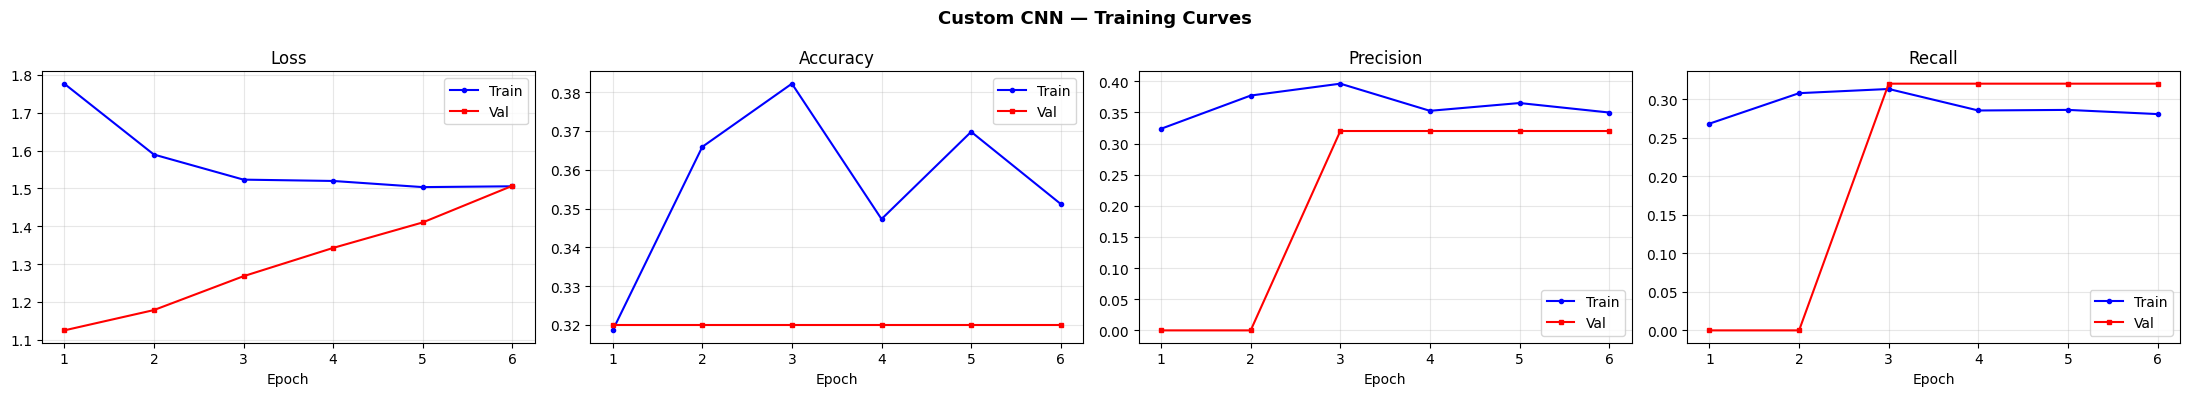



Classification Report:
              precision    recall  f1-score   support

 atelectasis       0.33      1.00      0.50       160
infiltration       0.00      0.00      0.00       158
  no finding       0.00      0.00      0.00       162

    accuracy                           0.33       480
   macro avg       0.11      0.33      0.17       480
weighted avg       0.11      0.33      0.17       480

Macro ROC-AUC : 0.5137



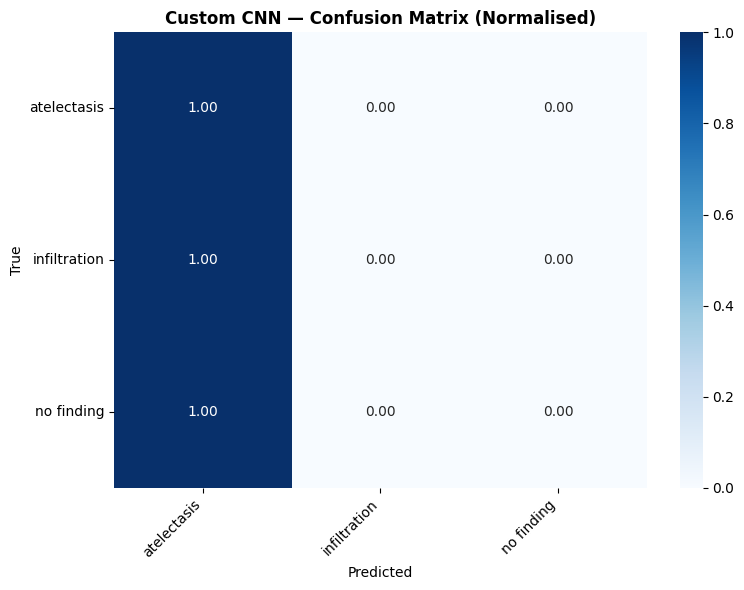

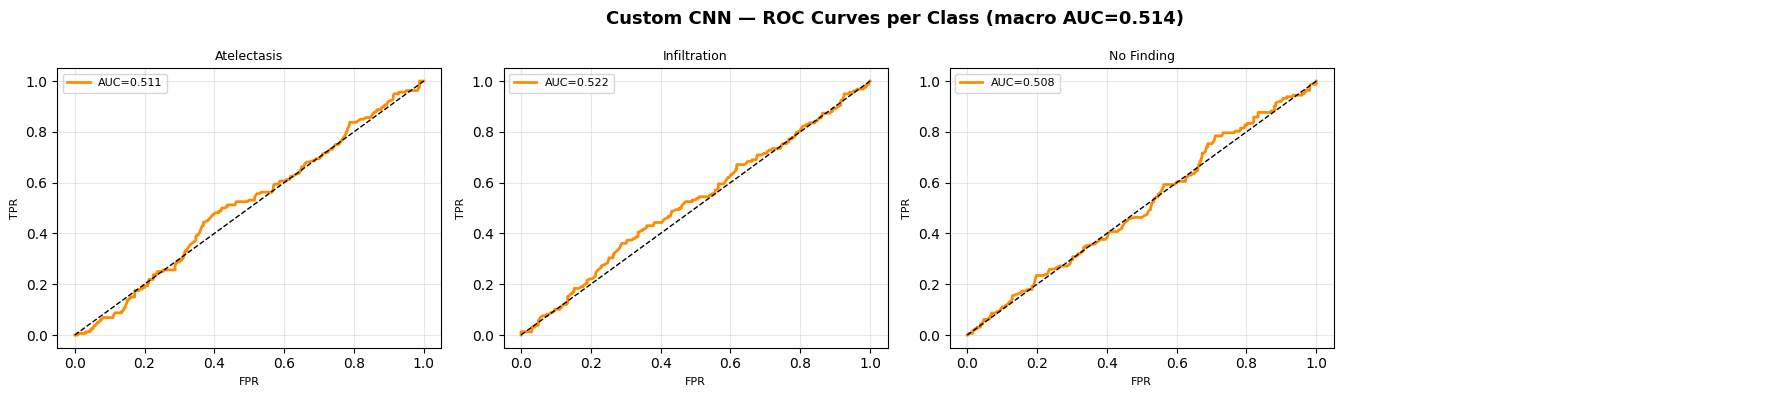

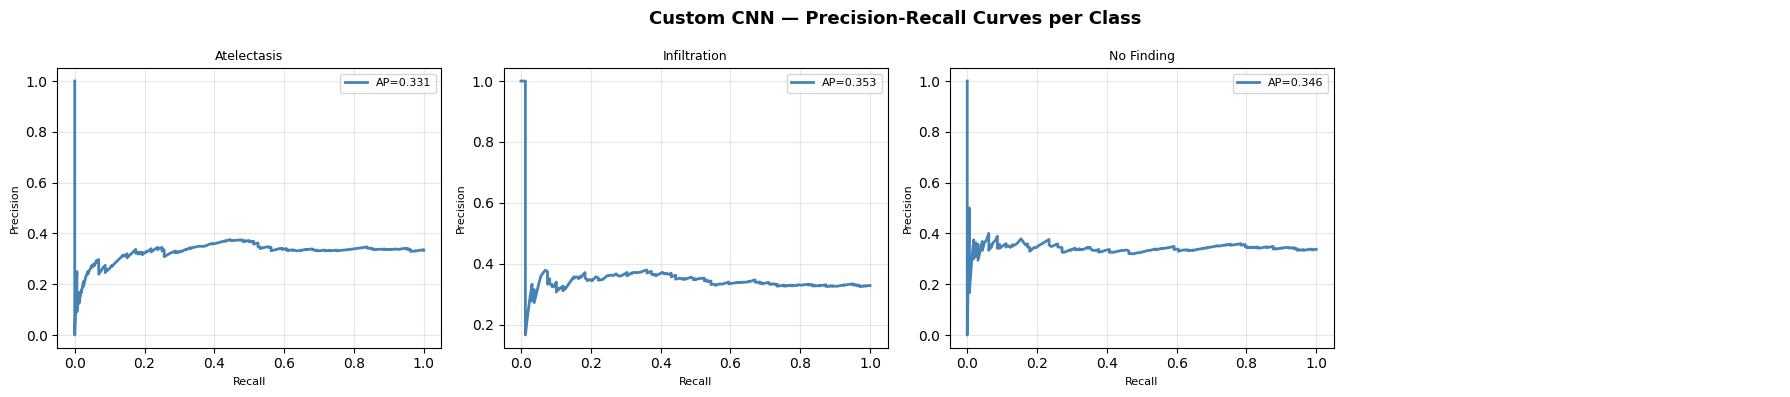


  MobileNetV2


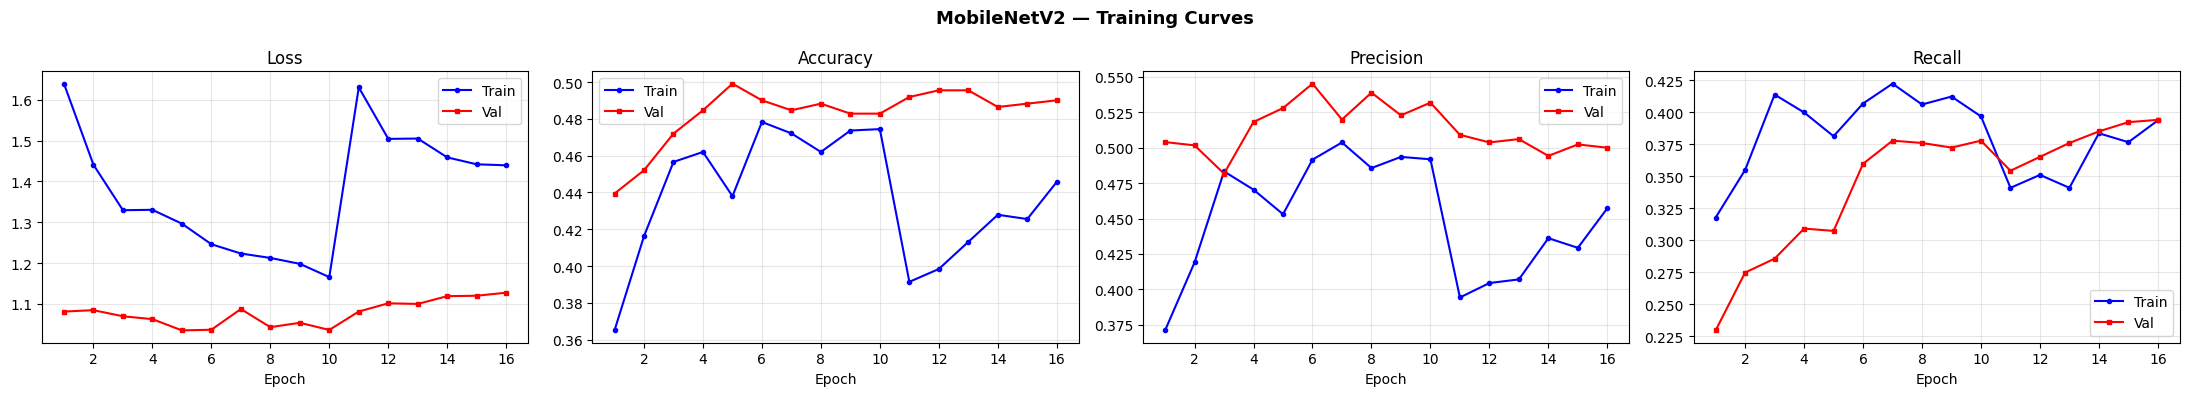



Classification Report:
              precision    recall  f1-score   support

 atelectasis       0.42      0.69      0.52       160
infiltration       0.32      0.13      0.18       158
  no finding       0.51      0.48      0.49       162

    accuracy                           0.43       480
   macro avg       0.42      0.43      0.40       480
weighted avg       0.42      0.43      0.40       480

Macro ROC-AUC : 0.6106



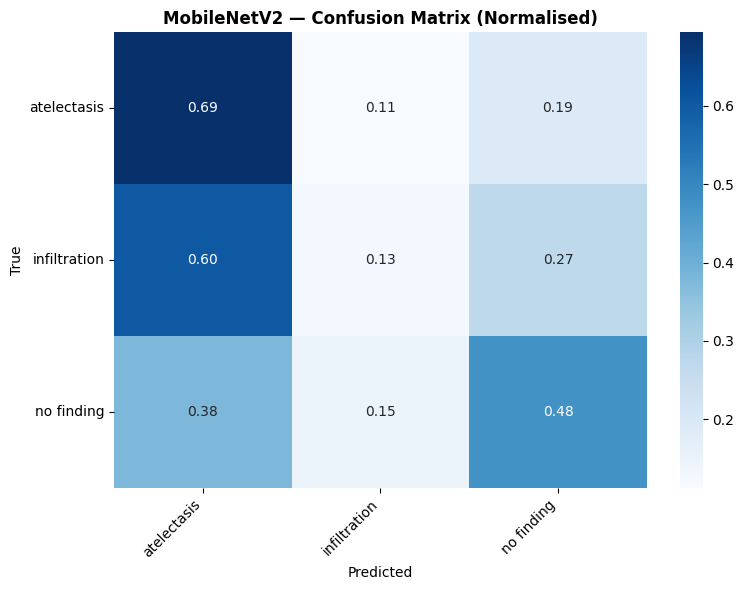

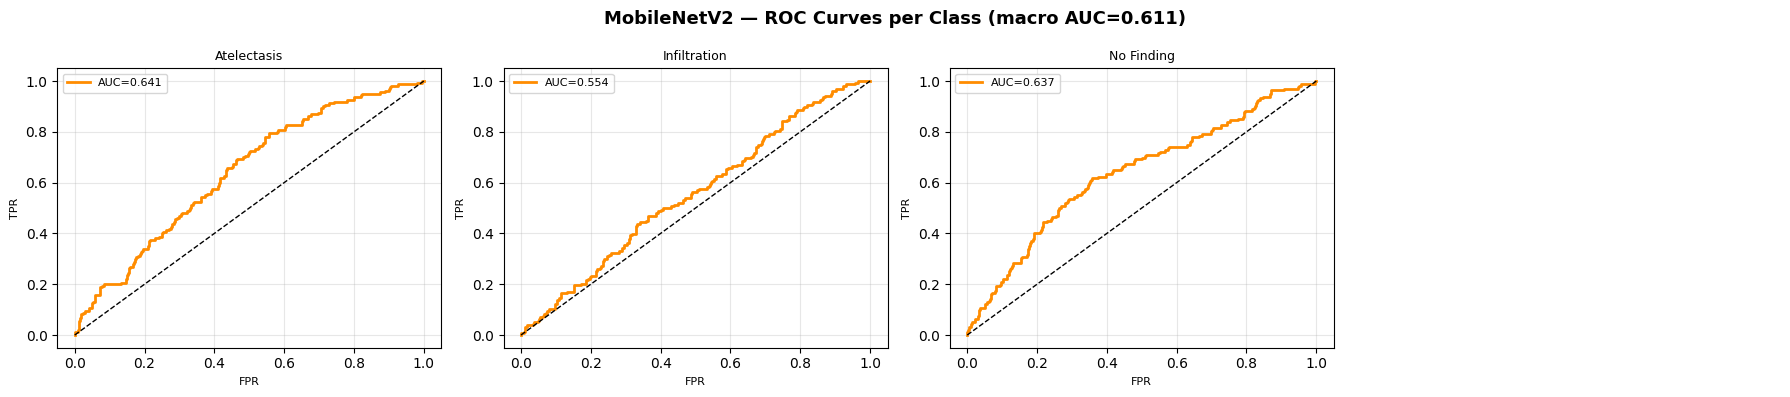

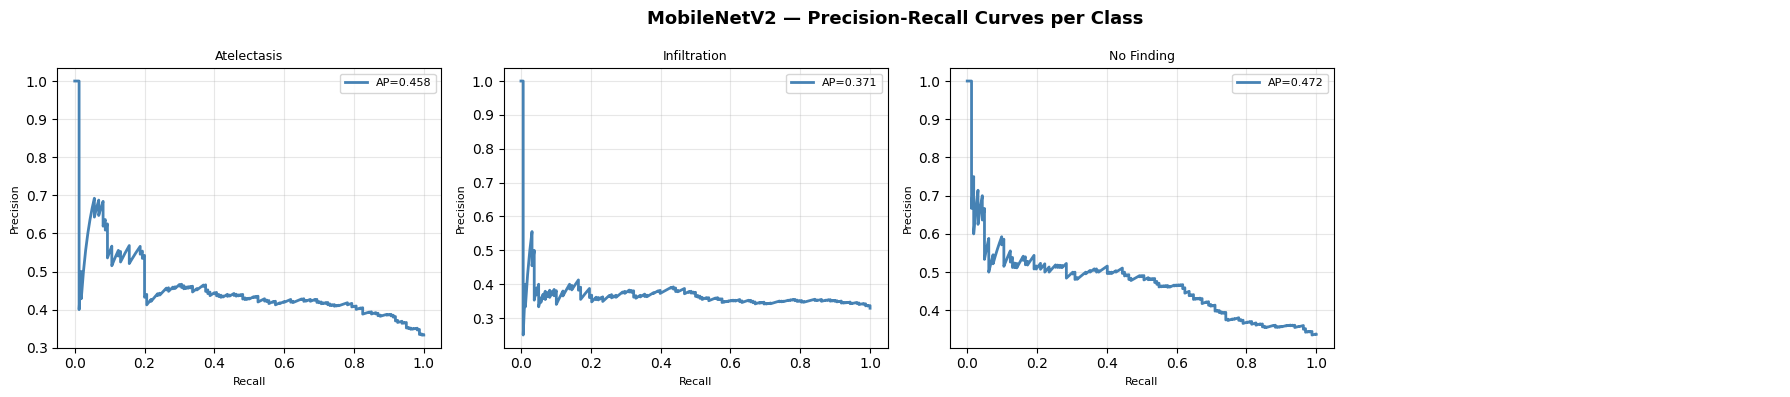


  DenseNet201


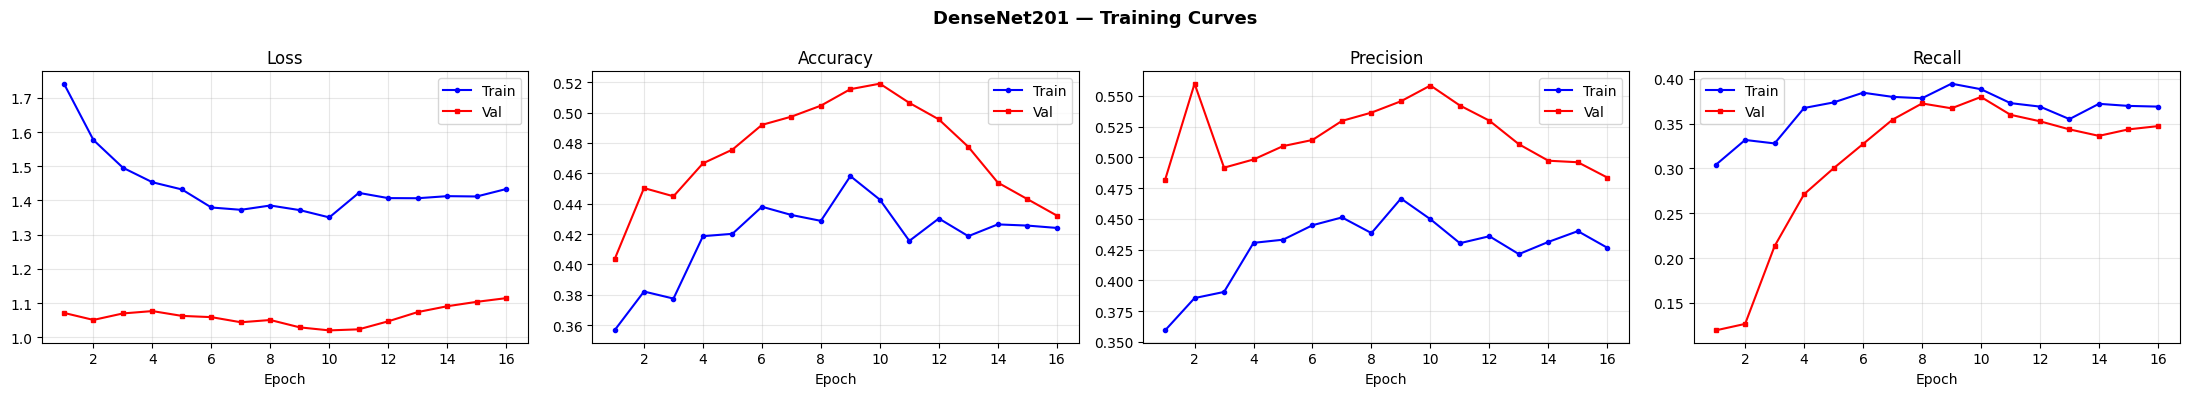



Classification Report:
              precision    recall  f1-score   support

 atelectasis       0.52      0.43      0.47       160
infiltration       0.43      0.69      0.53       158
  no finding       0.51      0.30      0.38       162

    accuracy                           0.47       480
   macro avg       0.49      0.47      0.46       480
weighted avg       0.49      0.47      0.46       480

Macro ROC-AUC : 0.6537



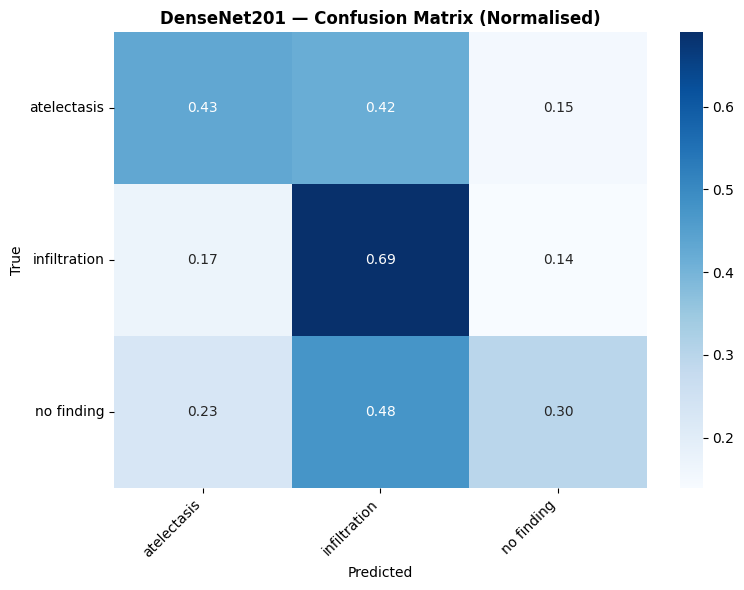

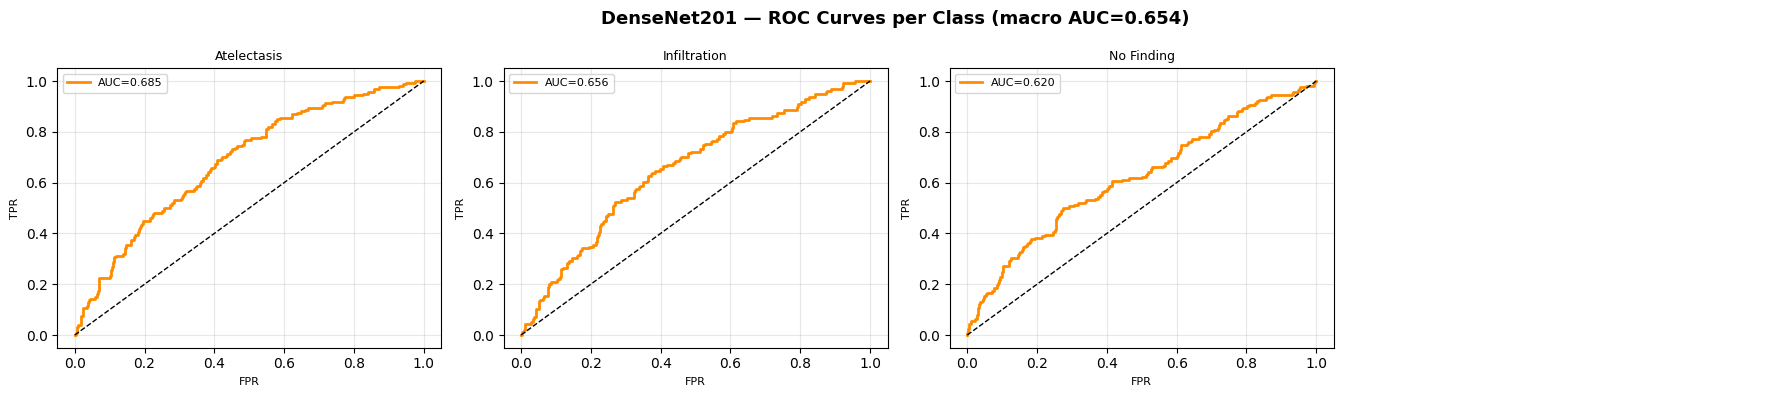

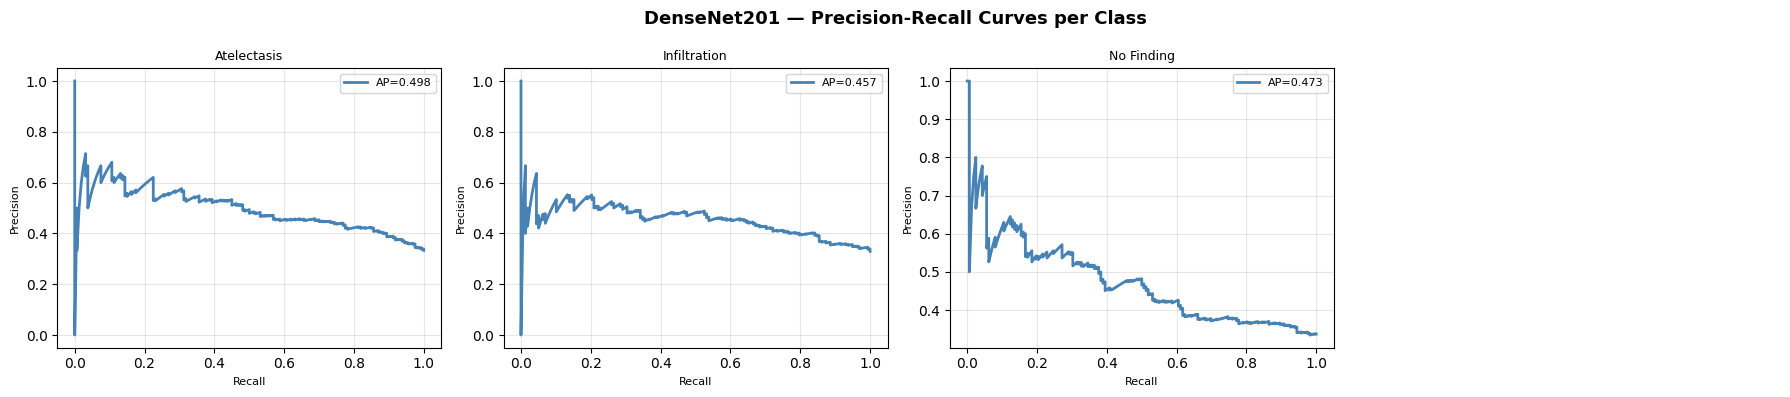

Per-model evaluation complete.


In [45]:
# Evaluate All Three Models
model_registry = [
    (cnn_model,       cnn_history,       "Custom CNN"),
    (mobilenet_model, mobilenet_history,  "MobileNetV2"),
    (densenet_model,  densenet_history,   "DenseNet201"),
]

all_metrics = []

for model, history, name in model_registry:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # 1. Training curves
    plot_training_curves(history, name)

    # 2. Metrics
    print()
    m = compute_metrics(model, test_gen, name)
    all_metrics.append(m)

    print(f"\nClassification Report:")
    print(classification_report(m['y_true'], m['y_pred'],
                                target_names=CLASS_NAMES, zero_division=0))
    print(f"Macro ROC-AUC : {m['roc_auc']:.4f}")

    # 3. Confusion matrix
    print()
    plot_confusion_matrix(m['cm'], CLASS_NAMES, name)

    # 4. ROC curves
    print()
    plot_roc_curves(m, CLASS_NAMES)

    # 5. Precision-Recall curves
    print()
    plot_precision_recall_curves(m, CLASS_NAMES)

print("Per-model evaluation complete.")

## **Master Comparison Plot — All Models × All Metrics**

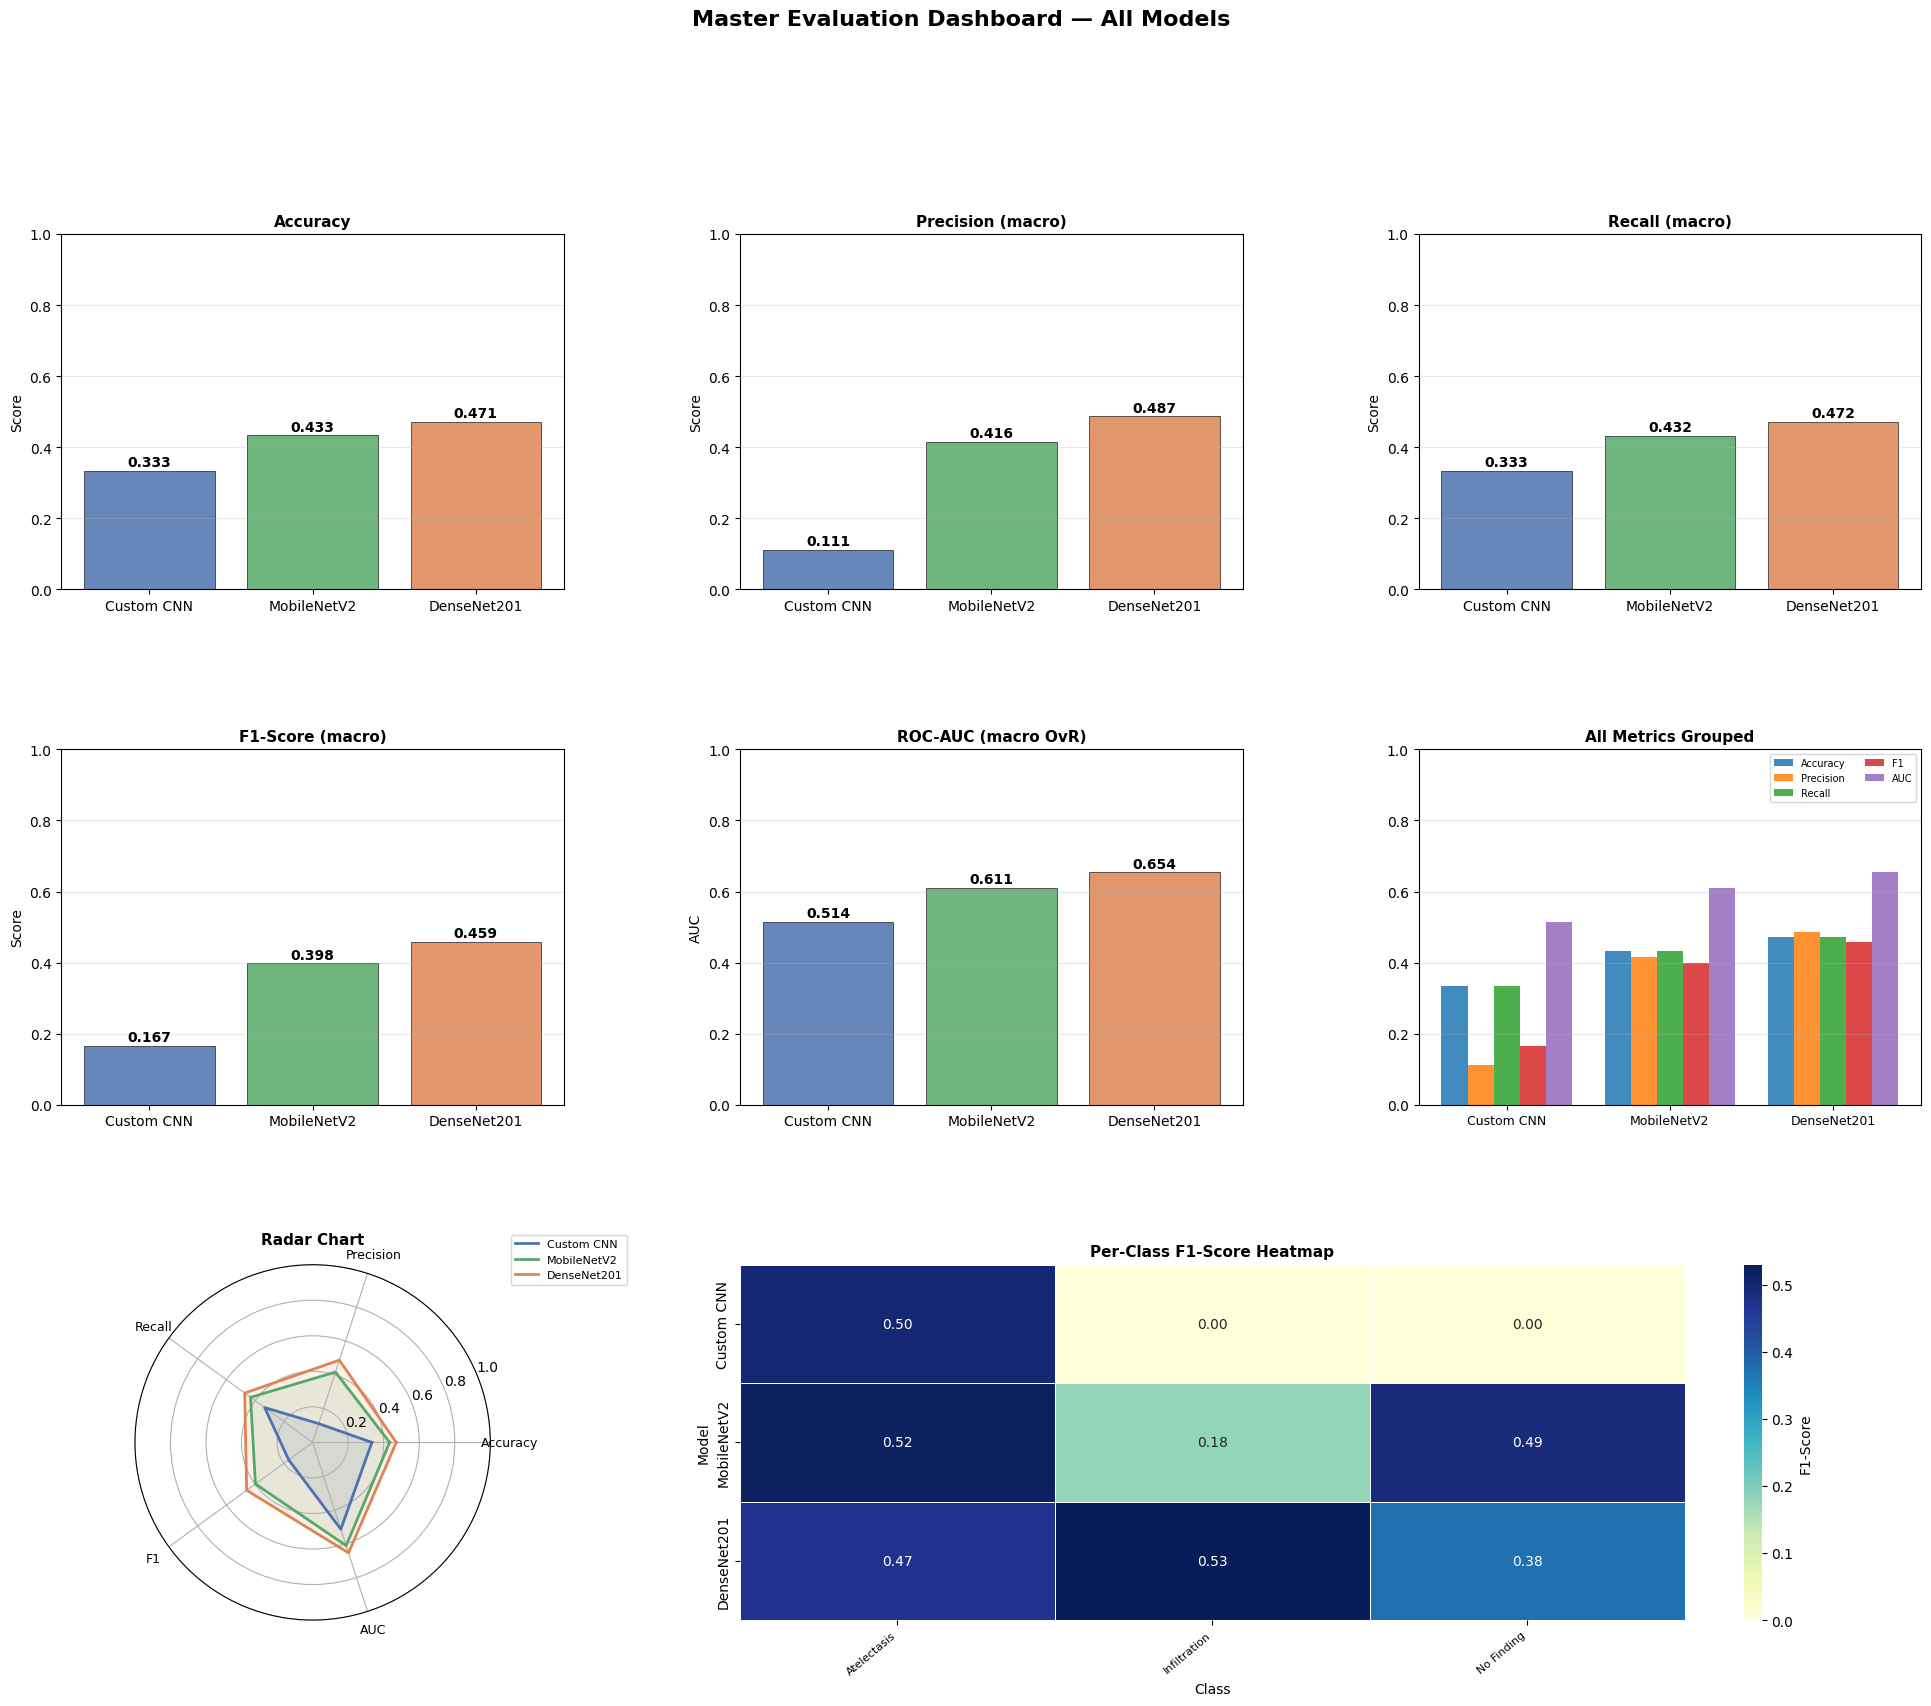

✅ Master dashboard saved.


In [39]:
# Master Comparison Dashboard

model_names = [m['name']      for m in all_metrics]
accuracies  = [m['accuracy']  for m in all_metrics]
precisions  = [m['precision'] for m in all_metrics]
recalls     = [m['recall']    for m in all_metrics]
f1_scores   = [m['f1']        for m in all_metrics]
roc_aucs    = [m['roc_auc']   for m in all_metrics]

palette = ['#4C72B0', '#55A868', '#DD8452']

fig = plt.figure(figsize=(24, 18))
fig.suptitle("Master Evaluation Dashboard — All Models",
             fontsize=16, fontweight='bold', y=1.005)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Subplot helper
def metric_bar(ax, values, title, ylabel, ylim=(0, 1)):
    bars = ax.bar(model_names, values, color=palette, alpha=0.85, edgecolor='black', lw=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_ylim(*ylim)
    ax.grid(axis='y', alpha=0.3)

# Row 0 — scalar metrics
metric_bar(fig.add_subplot(gs[0, 0]), accuracies,  "Accuracy",  "Score")
metric_bar(fig.add_subplot(gs[0, 1]), precisions,  "Precision (macro)", "Score")
metric_bar(fig.add_subplot(gs[0, 2]), recalls,     "Recall (macro)",    "Score")

# Row 1 — F1 + ROC-AUC + grouped bar
metric_bar(fig.add_subplot(gs[1, 0]), f1_scores,  "F1-Score (macro)",    "Score")
metric_bar(fig.add_subplot(gs[1, 1]), roc_aucs,   "ROC-AUC (macro OvR)", "AUC")

ax_grp = fig.add_subplot(gs[1, 2])
x  = np.arange(len(model_names))
w  = 0.16
for i, (vals, label) in enumerate(zip(
        [accuracies, precisions, recalls, f1_scores, roc_aucs],
        ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
)):
    ax_grp.bar(x + i * w, vals, w, label=label, alpha=0.85)
ax_grp.set_xticks(x + w * 2)
ax_grp.set_xticklabels(model_names, fontsize=9)
ax_grp.set_ylim(0, 1); ax_grp.set_title("All Metrics Grouped", fontsize=11, fontweight='bold')
ax_grp.legend(fontsize=7, ncol=2); ax_grp.grid(axis='y', alpha=0.3)

# Row 2 — Radar chart + per-class F1 heat-map
# Radar chart
ax_radar = fig.add_subplot(gs[2, 0], polar=True)
cats   = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
N      = len(cats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
for m, color in zip(all_metrics, palette):
    vals = [m['accuracy'], m['precision'], m['recall'], m['f1'], m['roc_auc']]
    vals += vals[:1]
    ax_radar.plot(angles, vals, color=color, linewidth=2, label=m['name'])
    ax_radar.fill(angles, vals, color=color, alpha=0.12)
ax_radar.set_xticks(angles[:-1]); ax_radar.set_xticklabels(cats, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title("Radar Chart", fontsize=11, fontweight='bold', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)

# Per-class F1 heatmap
ax_heat = fig.add_subplot(gs[2, 1:])
f1_matrix = np.array([
    [m['report'][cls]['f1-score'] for cls in CLASS_NAMES]
    for m in all_metrics
])
sns.heatmap(f1_matrix, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=[c.replace('_', ' ').title() for c in CLASS_NAMES],
            yticklabels=model_names, ax=ax_heat,
            linewidths=0.5, cbar_kws={'label': 'F1-Score'})
ax_heat.set_title("Per-Class F1-Score Heatmap", fontsize=11, fontweight='bold')
ax_heat.set_xlabel("Class"); ax_heat.set_ylabel("Model")
plt.setp(ax_heat.get_xticklabels(), rotation=40, ha='right', fontsize=8)

plt.savefig("master_evaluation_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Master dashboard saved.")

In [40]:
# ── Summary Table ──────────────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {
        'Model'            : m['name'],
        'Accuracy'         : f"{m['accuracy']:.4f}",
        'Precision (macro)': f"{m['precision']:.4f}",
        'Recall (macro)'   : f"{m['recall']:.4f}",
        'F1 (macro)'       : f"{m['f1']:.4f}",
        'ROC-AUC (macro)'  : f"{m['roc_auc']:.4f}",
    }
    for m in all_metrics
])
print(summary_df.to_string(index=False))

      Model Accuracy Precision (macro) Recall (macro) F1 (macro) ROC-AUC (macro)
 Custom CNN   0.3333            0.1111         0.3333     0.1667          0.5137
MobileNetV2   0.4333            0.4161         0.4319     0.3979          0.6106
DenseNet201   0.4708            0.4868         0.4725     0.4588          0.6537


## **Test Predictions — 10 Random Images (All Models)**

In [41]:
# Collect Test Image Paths
test_image_paths = []
test_image_labels = []

for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            test_image_paths.append(os.path.join(cls_path, fname))
            test_image_labels.append(cls)

# Sample 10 at random
selected_indices = random.sample(range(len(test_image_paths)), 10)
selected_paths   = [test_image_paths[i]  for i in selected_indices]
selected_labels  = [test_image_labels[i] for i in selected_indices]

print(f"Total test images : {len(test_image_paths)}")
print(f"Selected 10 paths : OK")

# Preprocess selected images
def preprocess_image(path, img_size):
    img  = Image.open(path).convert('RGB').resize(img_size)
    arr  = np.array(img, dtype=np.float32) / 255.0
    return arr

selected_arrays = np.stack([
    preprocess_image(p, IMG_SIZE) for p in selected_paths
])  # shape (10, H, W, 3)

Total test images : 480
Selected 10 paths : OK


In [42]:
# Get Predictions from All Models
predictions = {}
for model, _, name in model_registry:
    probs = model.predict(selected_arrays, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    predictions[name] = [
        (CLASS_NAMES[p], float(confs[i])) for i, p in enumerate(preds)
    ]
print("Predictions ready for all models.")

Predictions ready for all models.


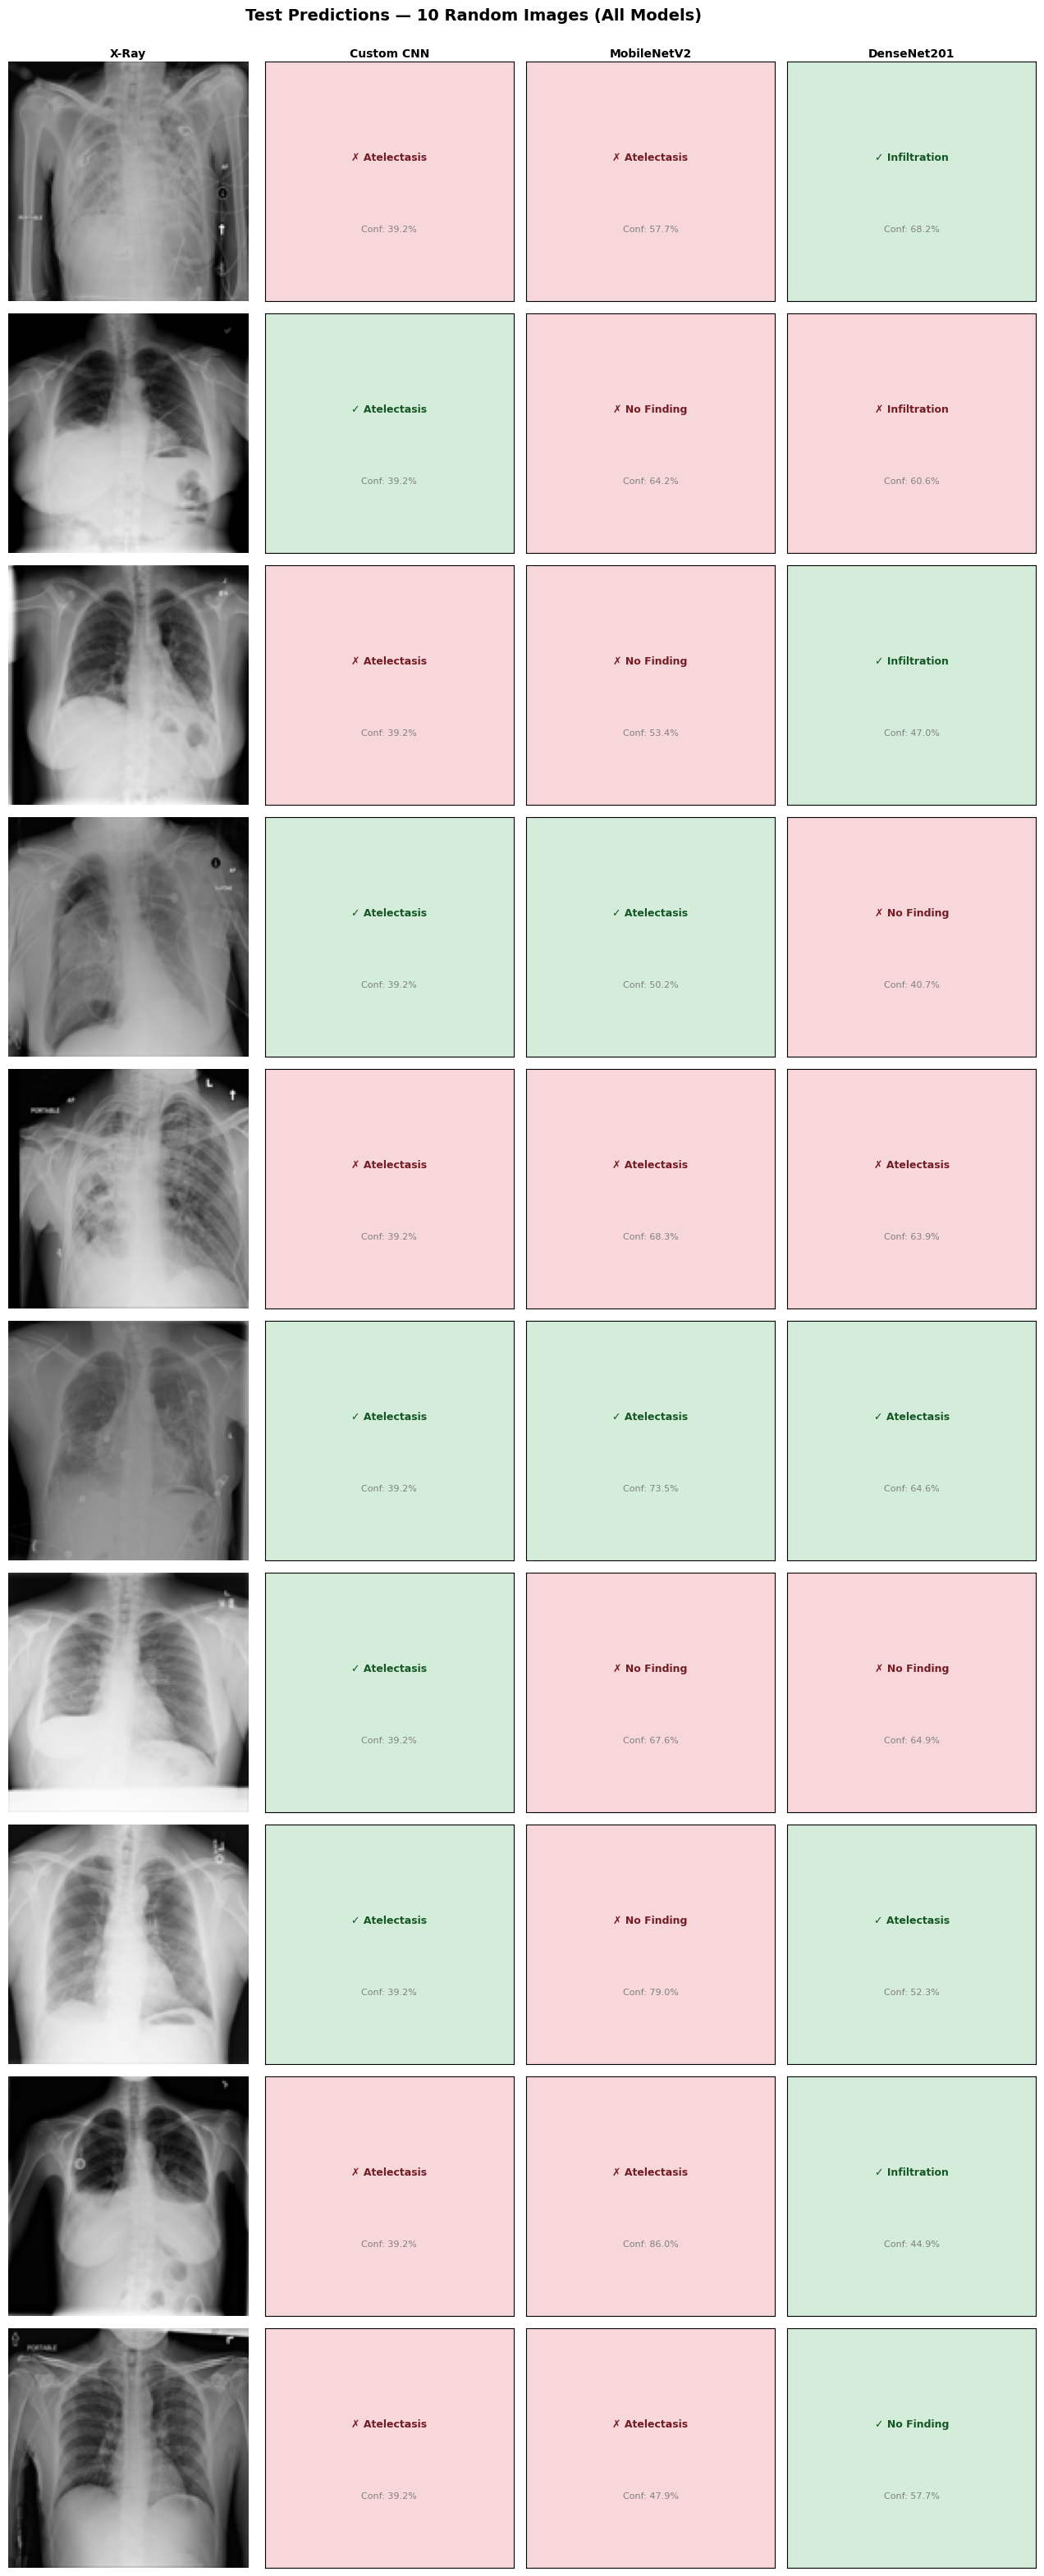

✅ Test prediction grid saved.


In [43]:
# Visualise — 10 Images × 3 Models
model_names_list = [name for _, _, name in model_registry]
N_IMGS     = 10
N_ROWS     = N_IMGS            # one row per image
N_COLS     = 1 + len(model_names_list)  # image + one column per model

fig, axes = plt.subplots(N_ROWS, N_COLS,
                          figsize=(N_COLS * 3.5, N_ROWS * 3.2))
fig.suptitle("Test Predictions — 10 Random Images (All Models)",
             fontsize=14, fontweight='bold')

# Column headers
col_titles = ["X-Ray"] + model_names_list
for col_idx, col_title in enumerate(col_titles):
    axes[0, col_idx].set_title(col_title, fontsize=10, fontweight='bold', pad=4)

for row_idx, (path, true_label) in enumerate(zip(selected_paths, selected_labels)):
    # Column 0: image
    img = Image.open(path).convert('RGB').resize((128, 128))
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_ylabel(
        f"Actual:\n{true_label.replace('_', ' ').title()}",
        fontsize=8, rotation=0, labelpad=80, va='center'
    )
    axes[row_idx, 0].axis('off')

    # Columns 1+: prediction cells
    for col_idx, model_name in enumerate(model_names_list, start=1):
        pred_label, conf = predictions[model_name][row_idx]
        correct = (pred_label.lower() == true_label.lower())
        bg      = '#d4edda' if correct else '#f8d7da'   # green / red tint
        tick    = '✓' if correct else '✗'

        ax = axes[row_idx, col_idx]
        ax.set_facecolor(bg)
        ax.text(0.5, 0.6, f"{tick} {pred_label.replace('_', ' ').title()}",
                ha='center', va='center', fontsize=9, fontweight='bold',
                transform=ax.transAxes,
                color='#155724' if correct else '#721c24')
        ax.text(0.5, 0.3, f"Conf: {conf*100:.1f}%",
                ha='center', va='center', fontsize=8,
                transform=ax.transAxes, color='gray')
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(rect=[0.08, 0, 1, 0.98])
plt.savefig("test_predictions_all_models.png", dpi=150, bbox_inches='tight')
plt.show()
print("Test prediction grid saved.")

## **Save Models**

In [44]:
os.makedirs("saved_models", exist_ok=True)
for model, _, name in model_registry:
    save_path = f"saved_models/{name.replace(' ', '_')}.keras"
    model.save(save_path)
    print(f"Saved: {save_path}")
print("ll models saved.")

Saved: saved_models/Custom_CNN.keras
Saved: saved_models/MobileNetV2.keras
Saved: saved_models/DenseNet201.keras

✅ All models saved.
